In [1]:
# Python import
import os
import copy
import random
import collections
import itertools
import numpy as np
import pandas as pd
import warnings
import joblib
from sklearn.model_selection import train_test_split,RandomizedSearchCV
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.utils import resample

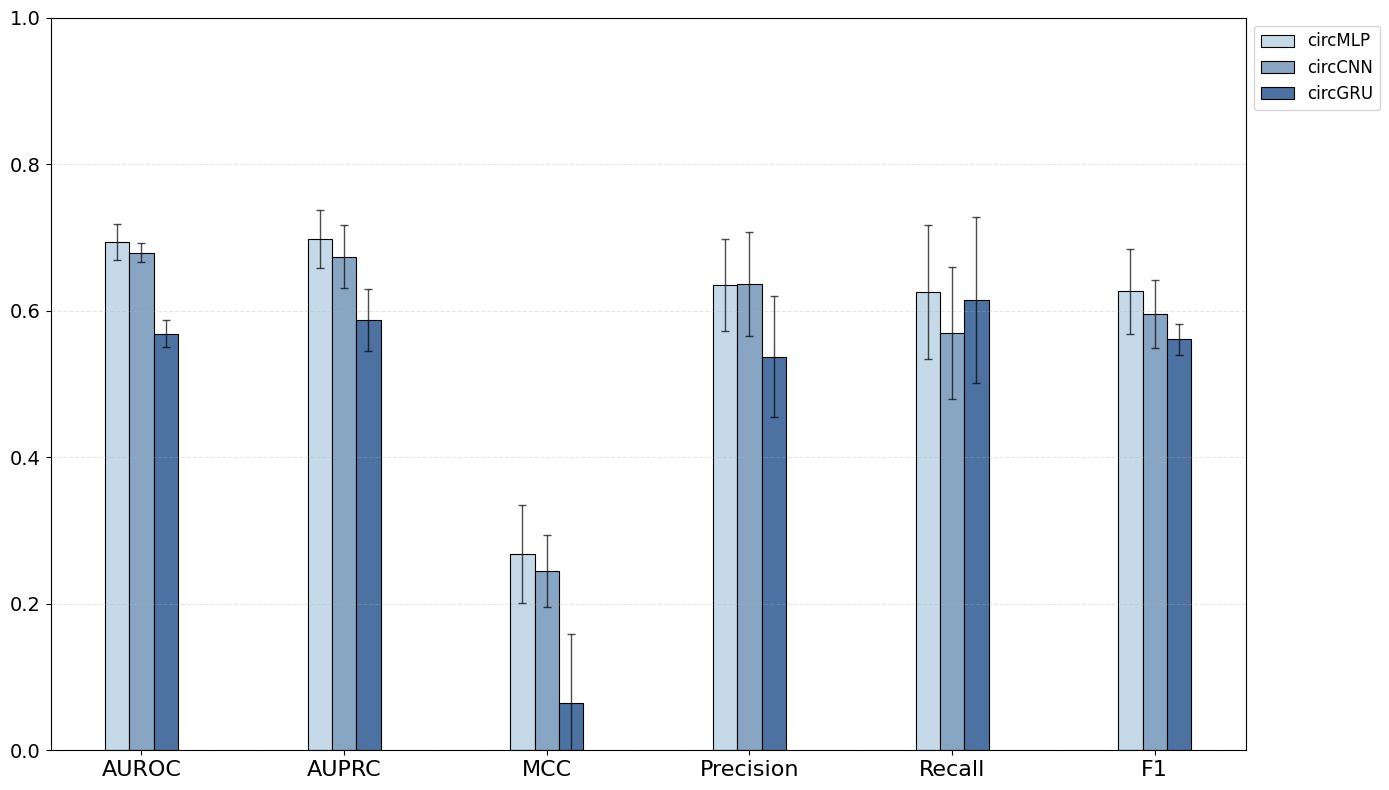

1. circMLP: AUROC = 0.6935 ± 0.0245
2. circCNN: AUROC = 0.6792 ± 0.0135
3. circGRU: AUROC = 0.5686 ± 0.0181


In [3]:
# 仅绘制三个DL模型的五折交叉验证结果
base_dir = '/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/DL_models/circRNA_DL_Model_tridivided_intra5fold_Output'
model_folders = {
    'CNN': 'circCNN',
    'GRU': 'circGRU',
    'MLP': 'circMLP'
}

csv_metrics = ['AUROC', 'AUPRC', 'MCC', 'Precision', 'Recall', 'F1_Score']
display_metrics = ['AUROC', 'AUPRC', 'MCC', 'Precision', 'Recall', 'F1']

original_models = []
original_mean_data = []
original_std_data = []

# 读取并计算均值和标准差
for folder, model_name in model_folders.items():
    csv_path = os.path.join(base_dir, folder, '5fold_cv_metrics.csv')
    df = pd.read_csv(csv_path)
    df_metrics = df[csv_metrics]
    
    original_mean_data.append(df_metrics.mean().values)
    original_std_data.append(df_metrics.std().values)
    original_models.append(model_name)

original_mean_data = np.array(original_mean_data)
original_std_data = np.array(original_std_data)

# 指定模型显示顺序
desired_order = ['circMLP', 'circCNN', 'circGRU']

# 根据指定顺序重新排列
sorted_indices = []
for model in desired_order:
    if model in original_models:
        sorted_indices.append(original_models.index(model))

# 重新排列模型和数据
models = [original_models[i] for i in sorted_indices]
data_mean = original_mean_data[sorted_indices]
data_std = original_std_data[sorted_indices]

# 配色方案 - 颜色依次加深
cool_colors = [
    '#D4E6F1', '#C5D9E8', '#B6CCDF', '#A7BFD6', '#98B2CD',
    '#89A5C4', '#7A98BB', '#6B8BB2', '#5C7EA9', '#4D71A0',
    '#3E6497', '#2F578E', '#204A85', '#113D7C'
]

# 为模型分配颜色，从浅到深
model_colors = [cool_colors[i] for i in [1, 5,  9]]


# 设置图形参数
fig, ax = plt.subplots(figsize=(14, 8))
n_metrics = len(display_metrics)
n_models = len(models)
bar_width = 0.12
x = np.arange(n_metrics)

# 绘制带有误差棒的分组柱状图
for i, model in enumerate(models):
    offset = (i - n_models/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, data_mean[i], bar_width, 
                  yerr=data_std[i], capsize=3,
                  label=model, color=model_colors[i], 
                  edgecolor='black', linewidth=0.8,
                  error_kw=dict(lw=1, capthick=1, alpha=0.7))

# 设置图形属性
ax.set_xticks(x)
ax.set_xticklabels(display_metrics, fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))

# 调整布局
plt.tight_layout()
plt.show()

for i, model in enumerate(models):
    print(f"{i+1}. {model}: AUROC = {data_mean[i][0]:.4f} ± {data_std[i][0]:.4f}")

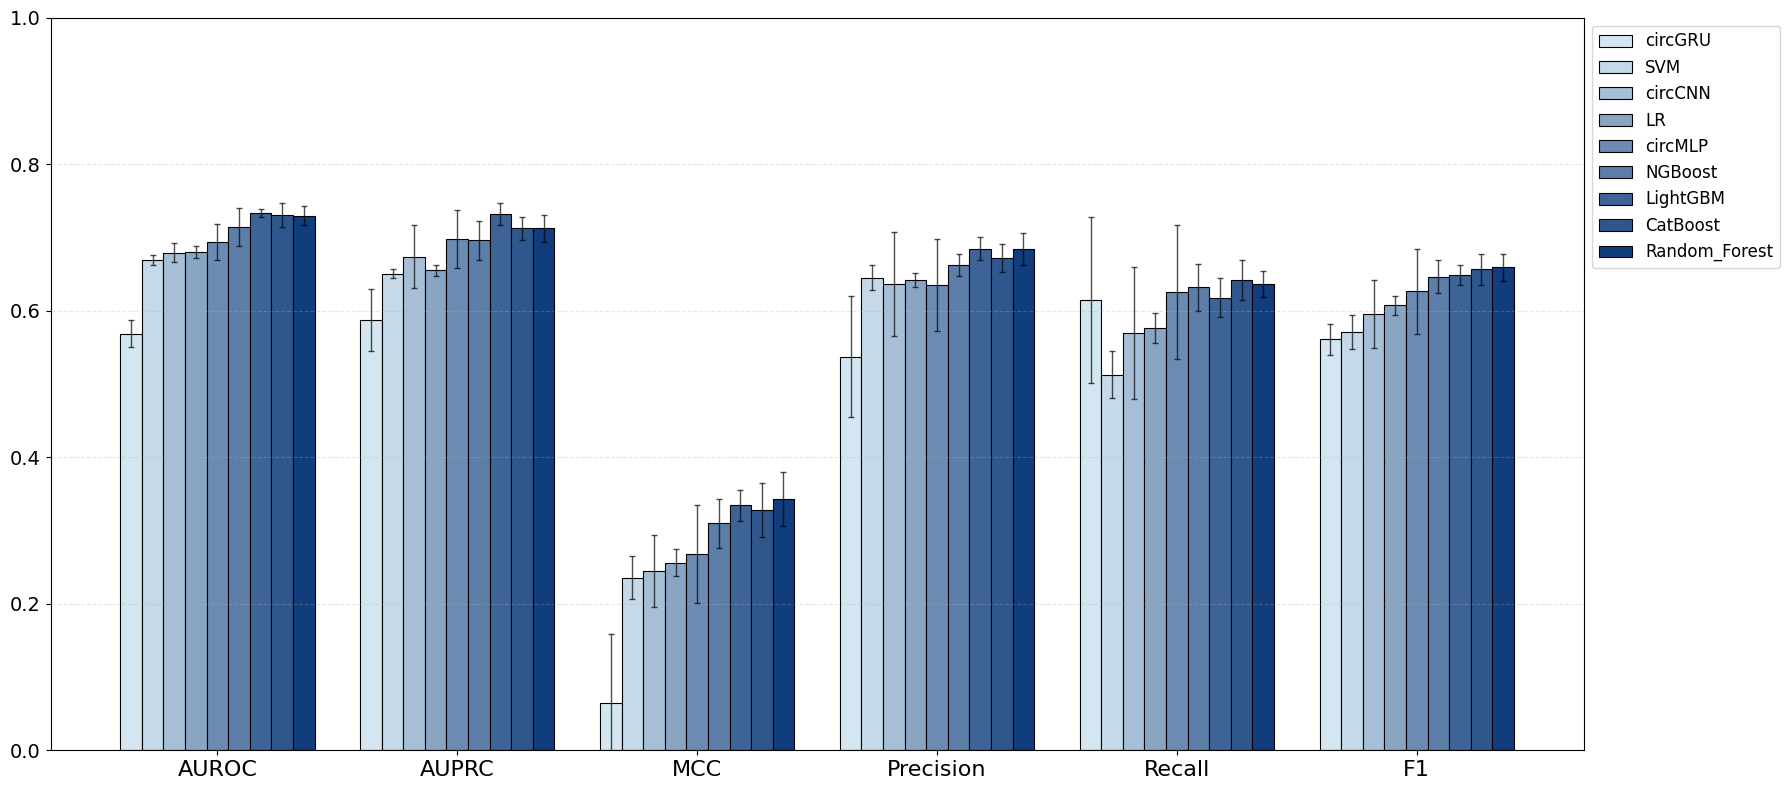

模型按F1均值从低到高排序:
1. circGRU: F1_Score = 0.5611 ± 0.0211
2. SVM: F1_Score = 0.5709 ± 0.0236
3. circCNN: F1_Score = 0.5954 ± 0.0465
4. LR: F1_Score = 0.6070 ± 0.0135
5. circMLP: F1_Score = 0.6263 ± 0.0579
6. NGBoost: F1_Score = 0.6463 ± 0.0222
7. LightGBM: F1_Score = 0.6489 ± 0.0136
8. CatBoost: F1_Score = 0.6561 ± 0.0205
9. Random_Forest: F1_Score = 0.6591 ± 0.0183


In [ ]:
# 纳入全部模型

# 1. 基础路径和文件夹配置 (包含 ML 和 DL 模型)
ml_base_dir = '/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_intra5fold_Output'
ml_model_folders = {
    'LogisticRegression': 'LR',
    'SVM': 'SVM',
    'CatBoost_RandomSearch': 'CatBoost',
    'LightGBM': 'LightGBM',
    'RandomForest': 'Random_Forest',
    'NGBoost_RandomSearch': 'NGBoost'
}

dl_base_dir = '/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/DL_models/circRNA_DL_Model_tridivided_intra5fold_Output'
dl_model_folders = {
    'CNN': 'circCNN',
    'GRU': 'circGRU',
    'MLP': 'circMLP'
}

csv_metrics = ['AUROC', 'AUPRC', 'MCC', 'Precision', 'Recall', 'F1_Score']
display_metrics = ['AUROC', 'AUPRC', 'MCC', 'Precision', 'Recall', 'F1']

original_models = []
original_mean_data = []
original_std_data = []

# 2. 读取并计算均值和标准差 - ML模型
for folder, model_name in ml_model_folders.items():
    csv_path = os.path.join(ml_base_dir, folder, '5fold_cv_metrics.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df_metrics = df[csv_metrics]
        original_mean_data.append(df_metrics.mean().values)
        original_std_data.append(df_metrics.std().values)
        original_models.append(model_name)
    else:
        print(f"Warning: ML model data not found at {csv_path}")

# 3. 读取并计算均值和标准差 - DL模型
for folder, model_name in dl_model_folders.items():
    csv_path = os.path.join(dl_base_dir, folder, '5fold_cv_metrics.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df_metrics = df[csv_metrics]
        original_mean_data.append(df_metrics.mean().values)
        original_std_data.append(df_metrics.std().values)
        original_models.append(model_name)
    else:
        print(f"Warning: DL model data not found at {csv_path}")

original_mean_data = np.array(original_mean_data)
original_std_data = np.array(original_std_data)

# 获取F1_Score的均值列 (对应索引5)
f1_idx = csv_metrics.index('F1_Score')
f1_values = original_mean_data[:, f1_idx]

# 根据F1_Score均值排序（从低到高）
sorted_indices = np.argsort(f1_values)

# 重新排列模型和数据
models = [original_models[i] for i in sorted_indices]
data_mean = original_mean_data[sorted_indices]
data_std = original_std_data[sorted_indices]

# 配色方案 - 颜色依次加深
cool_colors = [
    '#D4E6F1', '#C5D9E8', '#B6CCDF', '#A7BFD6', '#98B2CD',
    '#89A5C4', '#7A98BB', '#6B8BB2', '#5C7EA9', '#4D71A0',
    '#3E6497', '#2F578E', '#204A85', '#113D7C'
]

# 为9个模型选取颜色，从浅到深均匀分布
color_indices = [0, 1, 3, 5, 7, 8, 10, 11, 13]
model_colors = [cool_colors[i] for i in color_indices]

# 设置图形参数 (加宽figure以适应9个模型)
fig, ax = plt.subplots(figsize=(18, 8))
n_metrics = len(display_metrics)
n_models = len(models)
bar_width = 0.09 # 减小柱宽，适应9根柱子
x = np.arange(n_metrics)

# 绘制带有误差棒的分组柱状图
for i, model in enumerate(models):
    offset = (i - n_models/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, data_mean[i], bar_width, 
                  yerr=data_std[i], capsize=2,
                  label=model, color=model_colors[i], 
                  edgecolor='black', linewidth=0.8,
                  error_kw=dict(lw=1, capthick=1, alpha=0.7))

# 设置图形属性
ax.set_xticks(x)
ax.set_xticklabels(display_metrics, fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))

# 调整布局
plt.tight_layout()
plt.show()

# 打印排序后的模型顺序和对应的F1均值
print("模型按F1均值从低到高排序:")
for i, model in enumerate(models):
    print(f"{i+1}. {model}: F1_Score = {data_mean[i][f1_idx]:.4f} ± {data_std[i][f1_idx]:.4f}")

/tmp/ipykernel_530/196673504.py:64: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


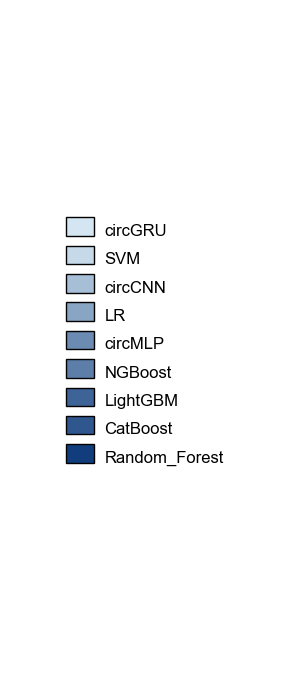

In [5]:
# 模型名称 (加入DL模型，共9个)
models = [
    'circGRU', 'SVM', 'circCNN', 'LR', 'circMLP', 
    'NGBoost', 'LightGBM', 'CatBoost', 'Random_Forest'
]

# 配色方案 - 使用cool_colors
cool_colors = [
    '#D4E6F1', '#C5D9E8', '#B6CCDF', '#A7BFD6', '#98B2CD',
    '#89A5C4', '#7A98BB', '#6B8BB2', '#5C7EA9', '#4D71A0',
    '#3E6497', '#2F578E', '#204A85', '#113D7C'
]

# 提取9个深浅不一的颜色
color_indices = [0, 1, 3, 5, 7, 8, 10, 11, 13]
base_9_colors = [cool_colors[i] for i in color_indices]

# 指定由浅到深的对应模型顺序
light_to_dark_order = [
    'circGRU', 'SVM', 'circCNN', 'LR', 'circMLP', 
    'NGBoost', 'LightGBM', 'CatBoost', 'Random_Forest'
]

# 为当前 models 列表中的每个模型匹配其对应的颜色
model_colors = []
for model in models:
    # 找到该模型在浅到深排序中的排位 (索引)
    rank = light_to_dark_order.index(model)
    # 取出对应排位的颜色
    model_colors.append(base_9_colors[rank])

# ===== 公共绘图函数 =====
def plot_model_legend(models, colors, filename, labelspacing=0.6, markersize=12, figsize=(3, 7)): # 增高figsize以适应9个模型
    """
    绘制模型与颜色对应的图例，并保存为透明背景图片
    专门用于堆积柱状图
    """
    plt.rcParams['font.family'] = 'Arial'
    fig, ax = plt.subplots(figsize=figsize)

    handles = []
    for model, color in zip(models, colors):
        # 使用矩形标记，更适合堆积柱状图
        patch = plt.Rectangle(
            (0, 0), 1, 1, facecolor=color, 
            edgecolor='black', linewidth=1,
            label=model
        )
        handles.append(patch)

    legend = ax.legend(
        handles=handles,
        labels=models,
        loc='center',
        ncol=1,
        frameon=False,
        labelspacing=labelspacing,  # 控制行间距
        handlelength=1.5,           # 图例标记长度
        handletextpad=0.8,          # 标记与文本间距
        fontsize=12                 # 字体大小
    )
    
    # 设置图例中矩形的大小
    for handle in legend.legendHandles:
        handle.set_width(markersize/10)
        handle.set_height(markersize/15)
    
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

# 调用函数生成图例
plot_model_legend(models, model_colors, "legend_models.png", labelspacing=0.8, markersize=200)

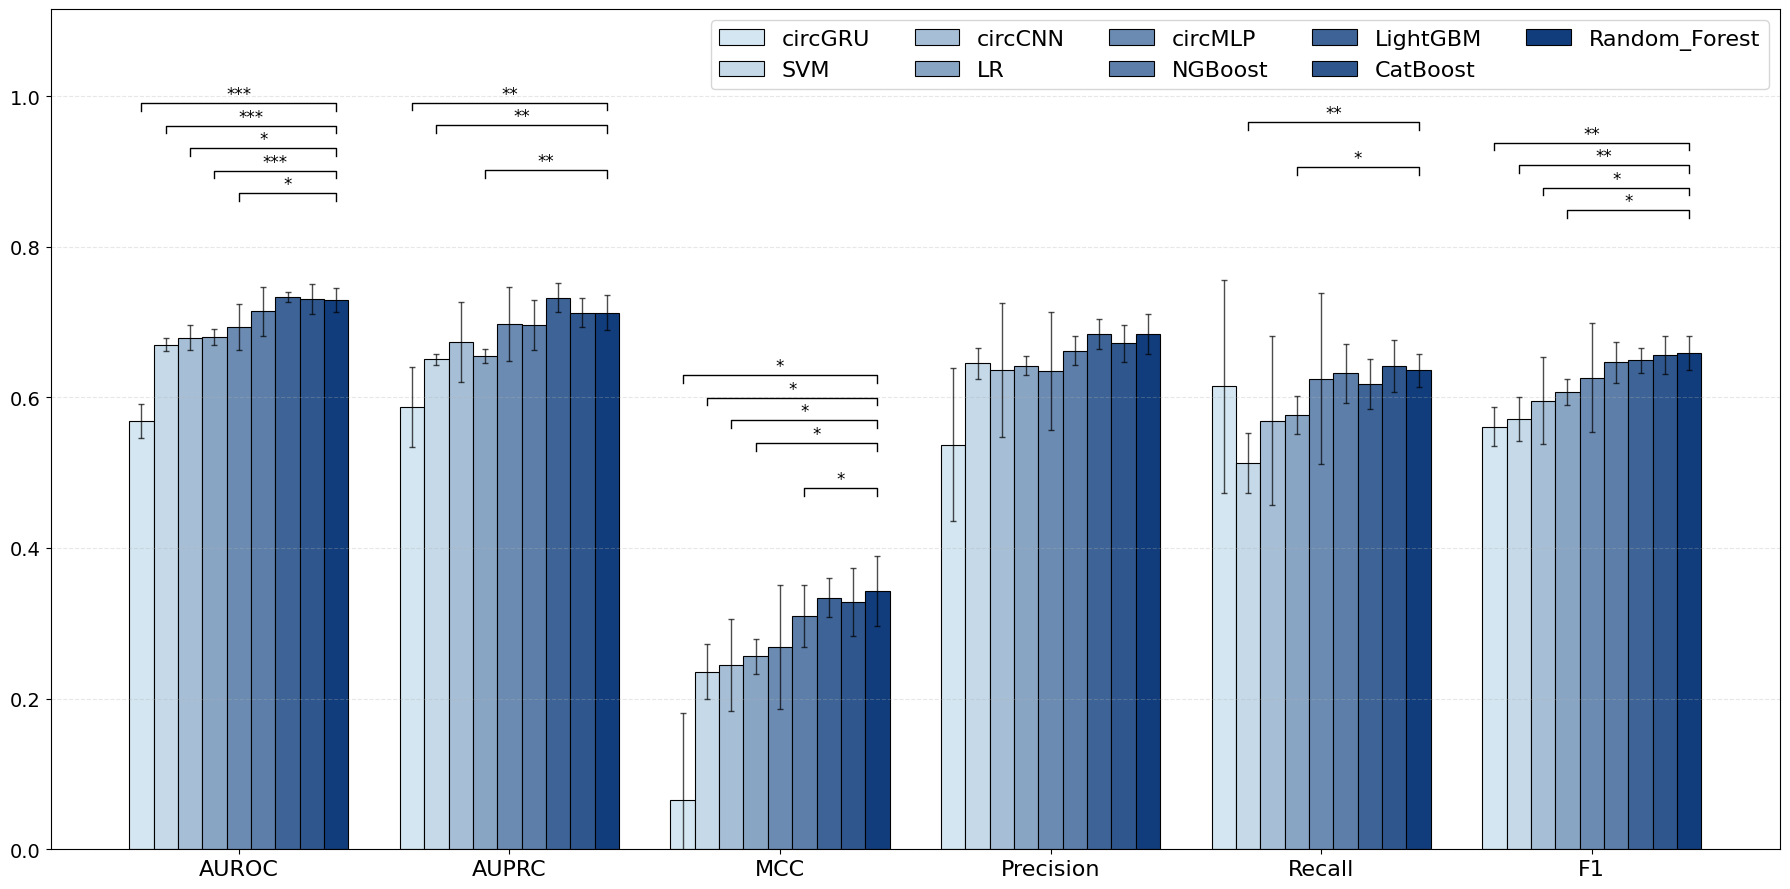

模型按F1均值从低到高排序 (均值 ± 95% CI):
1. circGRU: F1_Score = 0.5611 ± 0.0262
2. SVM: F1_Score = 0.5709 ± 0.0293
3. circCNN: F1_Score = 0.5954 ± 0.0577
4. LR: F1_Score = 0.6070 ± 0.0168
5. circMLP: F1_Score = 0.6263 ± 0.0719
6. NGBoost: F1_Score = 0.6463 ± 0.0276
7. LightGBM: F1_Score = 0.6489 ± 0.0169
8. CatBoost: F1_Score = 0.6561 ± 0.0255
9. Random_Forest: F1_Score = 0.6591 ± 0.0227


In [4]:
# 添加单位显著性检验，误差棒为 95% 置信区间 (95% CI)，包含 ML 和 DL 模型
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# --- 1. 基础路径和文件夹配置 (包含 ML 和 DL) ---
ml_base_dir = '/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_intra5fold_Output'
ml_model_folders = {
    'LogisticRegression': 'LR',
    'SVM': 'SVM',
    'CatBoost_RandomSearch': 'CatBoost',
    'LightGBM': 'LightGBM',
    'RandomForest': 'Random_Forest',
    'NGBoost_RandomSearch': 'NGBoost'
}

dl_base_dir = '/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/DL_models/circRNA_DL_Model_tridivided_intra5fold_Output'
dl_model_folders = {
    'CNN': 'circCNN',
    'GRU': 'circGRU',
    'MLP': 'circMLP'
}

csv_metrics = ['AUROC', 'AUPRC', 'MCC', 'Precision', 'Recall', 'F1_Score']
display_metrics = ['AUROC', 'AUPRC', 'MCC', 'Precision', 'Recall', 'F1']

original_models = []
original_mean_data = []
original_std_data = []
original_raw_data = [] # 用于存储每一折的原始数据以进行统计检验

# --- 2. 读取并计算均值和标准差 ---
# 读取 ML 模型数据
for folder, model_name in ml_model_folders.items():
    csv_path = os.path.join(ml_base_dir, folder, '5fold_cv_metrics.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df_metrics = df[csv_metrics]
        original_raw_data.append(df_metrics.values) 
        original_mean_data.append(df_metrics.mean().values)
        original_std_data.append(df_metrics.std().values)
        original_models.append(model_name)

# 读取 DL 模型数据
for folder, model_name in dl_model_folders.items():
    csv_path = os.path.join(dl_base_dir, folder, '5fold_cv_metrics.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df_metrics = df[csv_metrics]
        original_raw_data.append(df_metrics.values) 
        original_mean_data.append(df_metrics.mean().values)
        original_std_data.append(df_metrics.std().values)
        original_models.append(model_name)

original_mean_data = np.array(original_mean_data)
original_std_data = np.array(original_std_data)
original_raw_data = np.array(original_raw_data) # (9个模型, 5次CV, 6个指标)

# --- 3. 计算 95% 置信区间的半宽 (Confidence Interval Margin) ---
n_folds = 5
df_t = n_folds - 1  # 自由度
# 双侧 95% 置信区间对应的 t 临界值 (约 2.776)
t_critical = stats.t.ppf(1 - 0.05/2, df_t) 
original_ci_data = (original_std_data / np.sqrt(n_folds)) * t_critical

# --- 4. 根据 F1_Score 均值排序 ---
f1_idx = csv_metrics.index('F1_Score')
f1_values = original_mean_data[:, f1_idx]
sorted_indices = np.argsort(f1_values)

# 重新排列模型和数据
models = [original_models[i] for i in sorted_indices]
data_mean = original_mean_data[sorted_indices]
data_ci = original_ci_data[sorted_indices] # 使用 CI 作为误差
data_raw = original_raw_data[sorted_indices]

# --- 5. 颜色与绘图配置 ---
# 配色方案 - 颜色依次加深
cool_colors = [
    '#D4E6F1', '#C5D9E8', '#B6CCDF', '#A7BFD6', '#98B2CD',
    '#89A5C4', '#7A98BB', '#6B8BB2', '#5C7EA9', '#4D71A0',
    '#3E6497', '#2F578E', '#204A85', '#113D7C'
]

# 为9个模型选取颜色，从浅到深均匀分布
color_indices = [0, 1, 3, 5, 7, 8, 10, 11, 13]
model_colors = [cool_colors[i] for i in color_indices]

# 设置图形参数 (加宽以适应9个柱子)
fig, ax = plt.subplots(figsize=(18, 9))
n_metrics = len(display_metrics)
n_models = len(models)
bar_width = 0.09 # 调整为0.09以适应每组9个柱子
x = np.arange(n_metrics)

# 记录每个柱子的x坐标，结构为 (n_metrics, n_models)
bar_x_positions = np.zeros((n_metrics, n_models))

# 绘制带有误差棒的分组柱状图
for i, model in enumerate(models):
    offset = (i - n_models/2 + 0.5) * bar_width
    bar_x_positions[:, i] = x + offset
    bars = ax.bar(bar_x_positions[:, i], data_mean[i], bar_width, 
                  yerr=data_ci[i], capsize=2, #此处应用 data_ci 作为误差
                  label=model, color=model_colors[i], 
                  edgecolor='black', linewidth=0.8,
                  error_kw=dict(lw=1, capthick=1, alpha=0.7))

# --- 6. 添加显著性检验 (配对单尾t检验 + FDR校正) ---
def get_asterisks(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    return 'ns'

best_model_idx = n_models - 1 # 最右侧的模型索引（F1排在最后的）

for m_idx in range(n_metrics):
    p_values = []
    compare_indices = []
    
    # 提取最右侧模型在该指标下的5折结果
    best_raw = data_raw[best_model_idx, :, m_idx]
    
    # 与左侧所有模型比较
    for left_idx in range(n_models - 1):
        left_raw = data_raw[left_idx, :, m_idx]
        # 配对样本单尾t检验 (检验最右侧模型指标是否显著大于左侧模型)
        _, p_val = stats.ttest_rel(best_raw, left_raw, alternative='greater')
        p_values.append(p_val)
        compare_indices.append(left_idx)
        
    # 多重比较校正 (FDR Benjamini-Hochberg)
    _, p_adj, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
    
    # 画显著性连线和星号
    # 注意：这里高度要基于 mean + CI
    base_y_offset = max(data_mean[:, m_idx] + data_ci[:, m_idx]) + 0.02
    for offset_idx, (left_idx, p_val) in enumerate(zip(compare_indices, p_adj)):
        stars = get_asterisks(p_val)
        if stars != 'ns':
            x1 = bar_x_positions[m_idx, left_idx]
            x2 = bar_x_positions[m_idx, best_model_idx]
            # 为了避免线重合，根据跨度调整高度
            y = base_y_offset + (n_models - 2 - offset_idx) * 0.03
            h = 0.01
            
            # 绘制连线
            ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, color='black')
            # 绘制星号
            ax.text((x1+x2)/2, y+h, stars, ha='center', va='bottom', color='black', fontsize=12)

# --- 7. 设置图形属性 ---

ax.set_xticks(x)
ax.set_xticklabels(display_metrics, fontsize=16)
ax.tick_params(axis='y', labelsize=14)
# 根据加上显著性标记后的高度自动调整Y轴
ax.set_ylim(0, max(data_mean.flatten() + data_ci.flatten()) + (n_models * 0.04))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=16, loc='upper right', ncol=5)

# 调整布局
plt.tight_layout()
plt.show()

# --- 8. 打印排序后的模型顺序和对应的F1均值及95% CI ---
print("模型按F1均值从低到高排序 (均值 ± 95% CI):")
for i, model in enumerate(models):
    print(f"{i+1}. {model}: F1_Score = {data_mean[i][f1_idx]:.4f} ± {data_ci[i][f1_idx]:.4f}")

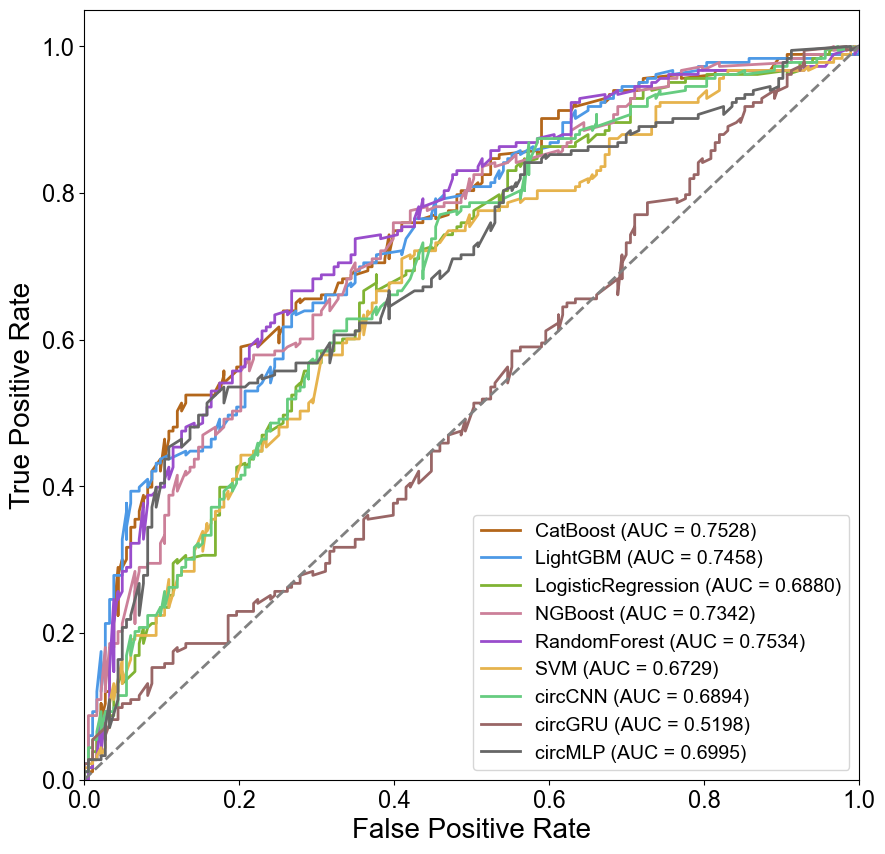

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def plot_AUROC(main_path):
    # Prepare figure and line width
    plt.figure(figsize=(10, 10)) # 加大画板以适应更多图例
    lw = 2
    
    # 增加到9种柔和的低饱和度颜色
    color_list = [
        (0.7, 0.4, 0.1),  # orange-ish
        (0.3, 0.6, 0.9),  # blue-ish
        (0.5, 0.7, 0.2),  # green-ish
        (0.8, 0.5, 0.6),  # pink-ish
        (0.6, 0.3, 0.8),  # purple-ish
        (0.9, 0.7, 0.3),  # yellow-ish
        (0.4, 0.8, 0.5),  # teal-ish
        (0.6, 0.4, 0.4),  # brown-ish
        (0.4, 0.4, 0.4)   # grey-ish
    ]
    
    # 1. 收集所有的模型及其对应的 AUROC_info.txt 路径
    model_paths = {}
    
    # 获取 ML 模型
    subfolders = sorted([d for d in os.listdir(main_path) if os.path.isdir(os.path.join(main_path, d))])
    for model in subfolders:
        model_paths[model] = os.path.join(main_path, model, 'AUROC_info.txt')
        
    # 获取 DL 模型 (手动添加绝对路径)
    dl_base = '/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/DL_models/circRNA_DL_Model_tridivided_intra5fold_Output'
    model_paths['circCNN'] = os.path.join(dl_base, 'CNN', 'CNN_Final_Model', 'AUROC_info.txt')
    model_paths['circGRU'] = os.path.join(dl_base, 'GRU', 'GRU_Final_Model', 'AUROC_info.txt')
    model_paths['circMLP'] = os.path.join(dl_base, 'MLP', 'MLP_Final_Model', 'AUROC_info.txt')
    
    # 给模型分配颜色
    model_list = list(model_paths.keys())
    model_colors = {model: color_list[i % len(color_list)] for i, model in enumerate(model_list)}
    
    # Function to load data from file and compute AUROC
    def load_roc_data(file_path):
        df = pd.read_csv(file_path, sep='\t')
        fpr = df['FPR'].values
        tpr = df['TPR'].values
        # Ensure fpr is sorted ascending (though it should be)
        sorted_idx = np.argsort(fpr)
        fpr = fpr[sorted_idx]
        tpr = tpr[sorted_idx]
        # Compute AUC using trapezoidal rule
        roc_auc = np.trapz(tpr, fpr)
        return fpr, tpr, roc_auc
    
    # Function to plot a single model's AUROC
    def plot_single_roc(fpr, tpr, roc_auc, label, color):
        plt.plot(fpr, tpr, color=color, lw=lw, label=f'{label} (AUC = {roc_auc:.4f})')
    
    # 2. 遍历字典，绘制每个模型的 AUROC
    for model, file_path in model_paths.items():
        if os.path.exists(file_path):
            fpr, tpr, roc_auc = load_roc_data(file_path)
            plot_single_roc(fpr, tpr, roc_auc, model, model_colors[model])
        else:
            print(f"Warning: File {file_path} not found. Skipping {model}.")
    
    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='grey', lw=lw, linestyle='--')

    # Customize the plot
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xticks(fontsize=17)
    plt.yticks(fontsize=17)
    plt.xlabel("False Positive Rate", fontsize=20)
    plt.ylabel("True Positive Rate", fontsize=20)
    plt.legend(loc="lower right", fontsize=14)
    
    # Save the plot
    plt.savefig(os.path.join(main_path, "AUROC_All_Models.pdf"), format="pdf")
    plt.show()

# Example usage:
plot_AUROC('/lulabdata3/huangkeyun/zhangys/RNA_locator/circExor/models/saved_models/circRNA_ML_Model_tridivided_Output')